In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit import RDConfig
from rdkit.Chem.Fingerprints import ClusterMols, DbFpSupplier, MolSimilarity, SimilarityScreener
from rdkit.Chem.Fingerprints import FingerprintMols as fp
from rdkit.Chem import AllChem, rdmolops, Lipinski, Descriptors
from rdkit.Chem.Descriptors import ExactMolWt, HeavyAtomMolWt, MolWt    
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.Avalon.pyAvalonTools import GetAvalonFP

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

In [5]:
data_ws = pd.read_csv('./data/ws496_logS.csv')
data_ws['SMILES'] = pd.Series(data_ws['SMILES'], dtype="string")
smiles_ws = data_ws.iloc[:,1]
y_ws = data_ws.iloc[:,2]

data_delaney = pd.read_csv('./data/delaney-processed.csv')
data_delaney['smiles'] = pd.Series(data_delaney['smiles'], dtype="string")
smiles_de = data_delaney.iloc[:,-1]
y_de= data_delaney.iloc[:,1]

data_lovric2020 = pd.read_csv('./data/Lovric2020_logS0.csv')
data_lovric2020['isomeric_smiles'] = pd.Series(data_lovric2020['isomeric_smiles'], dtype="string")
smiles_lo = data_lovric2020.iloc[:,0]
y_lo = data_lovric2020.iloc[:,1]

data_huuskonen = pd.read_csv('./data/huusk.csv')
data_huuskonen['SMILES'] = pd.Series(data_huuskonen['SMILES'], dtype="string")
smiles_hu = data_huuskonen.iloc[:,4]
y_hu = data_huuskonen.iloc[:,-1].astype('float')

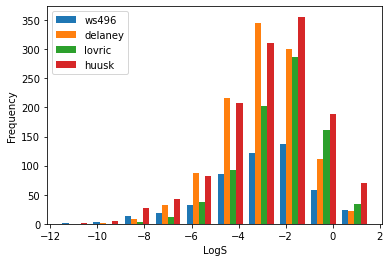

<Figure size 432x288 with 0 Axes>

In [6]:
plt.hist([y_ws, y_de,y_lo,y_hu], label=['ws496','delaney','lovric','huusk'])
plt.legend(loc='upper left')
plt.xlabel('LogS')
plt.ylabel('Frequency')
plt.savefig("1_LogS_Frequency.png", dpi=300)
plt.show()

In [7]:
def fp_converter(data):
    LEN_OF_FF = 2048
    mols = [Chem.MolFromSmiles(data) for data in data]
    ECFP = [AllChem.GetMorganFingerprintAsBitVect(data, 2, nBits=LEN_OF_FF) for data in mols]
    MACCS = [Chem.rdMolDescriptors.GetMACCSKeysFingerprint(data) for data in mols]
    AvalonFP = [GetAvalonFP(data) for data in mols]

    ECFP_container = []
    MACCS_container = []
    AvalonFP_container=AvalonFP
    for fps in ECFP:
        arr = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fps, arr)
        ECFP_container.append(arr)  
    
    for fps2 in MACCS:
        arr2 = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fps2, arr2)
        MACCS_container.append(arr2)
    
    ECFP_container = np.asarray(ECFP_container)
    MACCS_container = np.asarray(MACCS_container)
    AvalonFP_container = np.asarray(AvalonFP_container)    
    return mols, ECFP_container, MACCS_container, AvalonFP_container

In [8]:
mol_ws, x_ws, MACCS_ws, AvalonFP_ws = fp_converter(smiles_ws)
mol_de, x_de, MACCS_de, AvalonFP_de = fp_converter(smiles_de)
mol_lo, x_lo, MACCS_lo, AvalonFP_lo = fp_converter(smiles_lo)
mol_hu, x_hu, MACCS_hu, AvalonFP_hu = fp_converter(smiles_hu)

In [9]:
# x_ws.shape,MACCS_ws.shape,AvalonFP_ws.shape
# ((496, 2048), (496, 167), (496, 512))

In [10]:
xtr_ws, xte_ws, ytr_ws, yte_ws = train_test_split(x_ws, y_ws, test_size=0.2,random_state=42)
xtr_de, xte_de, ytr_de, yte_de = train_test_split(x_de, y_de, test_size=0.2,random_state=42)
xtr_lo, xte_lo, ytr_lo, yte_lo = train_test_split(x_lo, y_lo, test_size=0.2,random_state=42)
xtr_hu, xte_hu, ytr_hu, yte_hu = train_test_split(x_hu, y_hu, test_size=0.2,random_state=42)

In [11]:
def new_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            units=1024,
            activation='relu',
            kernel_initializer='glorot_uniform',
            kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(
            units=496,
            kernel_initializer='glorot_uniform',
            kernel_regularizer=regularizers.l2(1e-4),
            activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(units=1)
        ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                loss='mse', metrics=['mse', 'mae',tf.keras.metrics.RootMeanSquaredError()])
    return model

def multi_models(xtr, ytr):
    ridge = Ridge().fit(xtr,ytr)
    mlp = MLPRegressor(random_state=42, max_iter=350).fit(xtr,ytr)
    svr = SVR().fit(xtr,ytr)
    tmp = new_model()
    tmp.fit(xtr, ytr, epochs=100, batch_size=32, verbose=0)
    group = [ridge, mlp, svr, tmp]
    return group

In [12]:
ws_models = multi_models(xtr_ws, ytr_ws)
de_models = multi_models(xtr_de, ytr_de)
lo_models = multi_models(xtr_lo, ytr_lo)
hu_models = multi_models(xtr_hu, ytr_hu)

In [13]:
def print_metrics(dataset, model_name, ypre,yte):
    r2 = r2_score(yte,ypre)
    mae  = mean_absolute_error(yte,ypre)
    mse  = mean_squared_error(yte,ypre)
    rmse = mean_squared_error(yte,ypre, squared=False)
    print(f"[data : {dataset} ][model : {model_name} ] = r2 : {r2:.5f}, mae : {mae:.5f}, mse : {mse:.5f}, rmse : {rmse:.5f}")

In [14]:
def save_res(pred, truth):
    flat = pred[3].flatten()
    res = pd.DataFrame({'ytruth':truth,
                        'RR ':pred[0],
                        'MLP':pred[1],
                        'SVR':pred[2],
                        'DNN':flat,
                        }) #,   
    return res

In [15]:
print_metrics('ws','RID', ws_models[0].predict(xte_ws), yte_ws)
print_metrics('ws','MLP', ws_models[1].predict(xte_ws), yte_ws)
print_metrics('ws','SVR', ws_models[2].predict(xte_ws), yte_ws)
print_metrics('ws','DNN', ws_models[3].predict(xte_ws, verbose=0), yte_ws)
res_rid = ws_models[0].predict(xte_ws)
res_mlp = ws_models[1].predict(xte_ws)
res_svr = ws_models[2].predict(xte_ws)
res_dnn = ws_models[3].predict(xte_ws, verbose=0)
ws_res_all = save_res([res_rid,res_mlp,res_svr,res_dnn], yte_ws)

[data : ws ][model : RID ] = r2 : 0.54668, mae : 0.94605, mse : 1.47901, rmse : 1.21615
[data : ws ][model : MLP ] = r2 : 0.46770, mae : 1.04292, mse : 1.73667, rmse : 1.31783
[data : ws ][model : SVR ] = r2 : 0.57950, mae : 0.92607, mse : 1.37192, rmse : 1.17129
[data : ws ][model : DNN ] = r2 : 0.60114, mae : 0.90621, mse : 1.30130, rmse : 1.14075


In [16]:
print_metrics('de','RID', de_models[0].predict(xte_de), yte_de)
print_metrics('de','MLP', de_models[1].predict(xte_de), yte_de)
print_metrics('de','SVR', de_models[2].predict(xte_de), yte_de)
print_metrics('de','DNN', de_models[3].predict(xte_de, verbose=0), yte_de)
res_rid = de_models[0].predict(xte_de)
res_mlp = de_models[1].predict(xte_de)
res_svr = de_models[2].predict(xte_de)
res_dnn = de_models[3].predict(xte_de, verbose=0)
de_res_all = save_res([res_rid,res_mlp,res_svr,res_dnn], yte_de)

[data : de ][model : RID ] = r2 : 0.75780, mae : 0.56116, mse : 0.72274, rmse : 0.85014
[data : de ][model : MLP ] = r2 : 0.74306, mae : 0.60988, mse : 0.76671, rmse : 0.87562
[data : de ][model : SVR ] = r2 : 0.73070, mae : 0.58215, mse : 0.80360, rmse : 0.89644
[data : de ][model : DNN ] = r2 : 0.82714, mae : 0.48572, mse : 0.51582, rmse : 0.71821


In [17]:
print_metrics('lo','RID', lo_models[0].predict(xte_lo), yte_lo)
print_metrics('lo','MLP', lo_models[1].predict(xte_lo), yte_lo)
print_metrics('lo','SVR', lo_models[2].predict(xte_lo), yte_lo)
print_metrics('lo','DNN', lo_models[3].predict(xte_lo, verbose=0), yte_lo)
res_rid = lo_models[0].predict(xte_lo)
res_mlp = lo_models[1].predict(xte_lo)
res_svr = lo_models[2].predict(xte_lo)
res_dnn = lo_models[3].predict(xte_lo, verbose=0)
lo_res_all = save_res([res_rid,res_mlp,res_svr,res_dnn], yte_lo)

[data : lo ][model : RID ] = r2 : 0.58814, mae : 0.74867, mse : 1.09010, rmse : 1.04408
[data : lo ][model : MLP ] = r2 : 0.59706, mae : 0.73588, mse : 1.06648, rmse : 1.03270
[data : lo ][model : SVR ] = r2 : 0.58926, mae : 0.70654, mse : 1.08712, rmse : 1.04265
[data : lo ][model : DNN ] = r2 : 0.61572, mae : 0.73711, mse : 1.01709, rmse : 1.00851


In [18]:
print_metrics('ws','RID', hu_models[0].predict(xte_hu), yte_hu)
print_metrics('ws','MLP', hu_models[1].predict(xte_hu), yte_hu)
print_metrics('ws','SVR', hu_models[2].predict(xte_hu), yte_hu)
print_metrics('ws','DNN', hu_models[3].predict(xte_hu, verbose=0), yte_hu)
res_rid = hu_models[0].predict(xte_hu)
res_mlp = hu_models[1].predict(xte_hu)
res_svr = hu_models[2].predict(xte_hu)
res_dnn = hu_models[3].predict(xte_hu, verbose=0)
hu_res_all = save_res([res_rid,res_mlp,res_svr,res_dnn], yte_hu)

[data : ws ][model : RID ] = r2 : 0.64383, mae : 0.91193, mse : 1.58124, rmse : 1.25747
[data : ws ][model : MLP ] = r2 : 0.64013, mae : 0.91304, mse : 1.59767, rmse : 1.26399
[data : ws ][model : SVR ] = r2 : 0.68278, mae : 0.87627, mse : 1.40830, rmse : 1.18672
[data : ws ][model : DNN ] = r2 : 0.74875, mae : 0.78147, mse : 1.11546, rmse : 1.05615


In [19]:
groupA = ['ws496', ws_res_all]
groupB = ['delaney', de_res_all]
groupC = ['lovrics', lo_res_all]
groupD = ['Huusken', hu_res_all]
res_datasets = [groupA, groupB, groupC, groupD]

In [42]:
i=1
input = f'14{i}'
int(input), type(int(input))

(141, int)

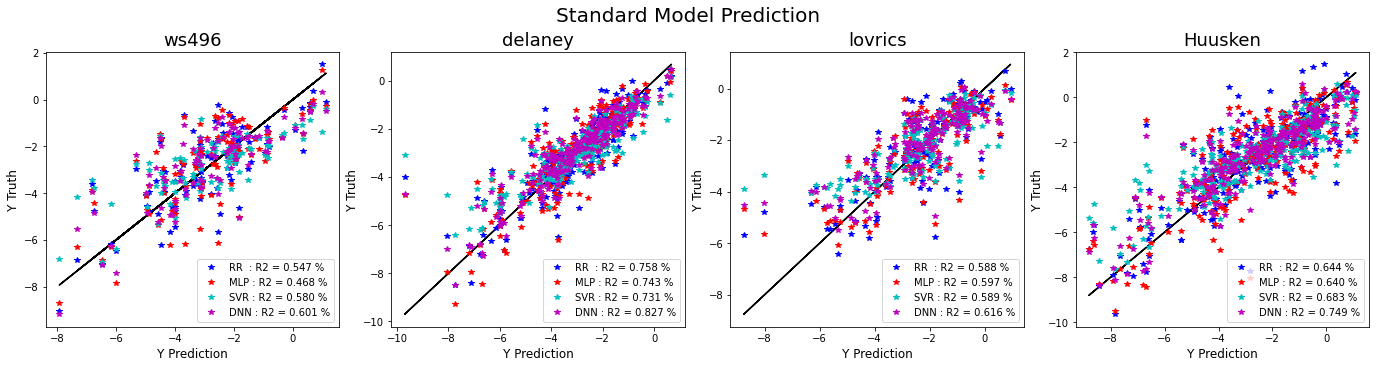

In [56]:
def vis_res(res_datasets):
    fig = plt.figure(constrained_layout=True, figsize=(19, 5))
    fig.suptitle("Standard Model Prediction", fontsize=20)  
    for i,k in enumerate(res_datasets):
        input = f'14{i+1}'
        ax = fig.add_subplot(int(input))
        ax.set_title(k[0],fontsize=18)
        ax.plot(k[1].iloc[:,0],k[1].iloc[:,0],'k-')
        ax.plot(k[1].iloc[:,0],k[1].iloc[:,1],'b*',label=f'{k[1].columns.values[1]} : R2 = %.3f %%' % (r2_score(k[1].iloc[:,0],k[1].iloc[:,1])))
        ax.plot(k[1].iloc[:,0],k[1].iloc[:,2],'r*',label=f'{k[1].columns.values[2]} : R2 = %.3f %%' % (r2_score(k[1].iloc[:,0],k[1].iloc[:,2])))
        ax.plot(k[1].iloc[:,0],k[1].iloc[:,3],'c*',label=f'{k[1].columns.values[3]} : R2 = %.3f %%' % (r2_score(k[1].iloc[:,0],k[1].iloc[:,3])))
        ax.plot(k[1].iloc[:,0],k[1].iloc[:,4],'m*',label=f'{k[1].columns.values[4]} : R2 = %.3f %%' % (r2_score(k[1].iloc[:,0],k[1].iloc[:,4])))
        ax.legend(loc=4)
        ax.set_ylabel('Y Truth', fontsize=12)
        ax.set_xlabel('Y Prediction', fontsize=12)
    # fig.tight_layout()
    plt.savefig("1_standard_model_compare.png",dpi=300)
    plt.show()
vis_res(res_datasets)